Import Libraries and Package

In [120]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Upload Dataset and read

In [121]:
df = pd.read_csv('/content/employee_salary_dataset.csv')

In [122]:
df

,Age,Experience,Education_Level,Job_Role,Location,Hours_Per_Week,Salary
0,30,7,Bachelors,Sales Executive,Pune,53,58129.28
1,25,4,Bachelors,Data Analyst,Hyderabad,45,52282.82
2,33,8,Bachelors,HR Executive,Mumbai,36,67712.17
3,27,5,Masters,HR Executive,Ahmedabad,44,66802.54
4,32,7,Masters,Accountant,Ahmedabad,45,69057.07
...,...,...,...,...,...,...,...
895,23,1,Bachelors,HR Executive,Mumbai,47,40226.99
896,35,9,High School,HR Executive,Pune,45,57336.12
897,33,8,Bachelors,Accountant,Ahmedabad,56,62198.75
898,35,6,Bachelors,Manager,Ahmedabad,38,70024.78


remove unnecessary column

In [123]:
df.drop(columns='Hours_Per_Week', inplace=True)

Show top 5 rows

In [124]:
df.head()

,Age,Experience,Education_Level,Job_Role,Location,Salary
0,30,7,Bachelors,Sales Executive,Pune,58129.28
1,25,4,Bachelors,Data Analyst,Hyderabad,52282.82
2,33,8,Bachelors,HR Executive,Mumbai,67712.17
3,27,5,Masters,HR Executive,Ahmedabad,66802.54
4,32,7,Masters,Accountant,Ahmedabad,69057.07


show bottom 5 rows

In [125]:
df.tail()

,Age,Experience,Education_Level,Job_Role,Location,Salary
895,23,1,Bachelors,HR Executive,Mumbai,40226.99
896,35,9,High School,HR Executive,Pune,57336.12
897,33,8,Bachelors,Accountant,Ahmedabad,62198.75
898,35,6,Bachelors,Manager,Ahmedabad,70024.78
899,32,7,Masters,Designer,Hyderabad,68959.18


show information

In [126]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Age              900 non-null    int64  
 1   Experience       900 non-null    int64  
 2   Education_Level  900 non-null    object 
 3   Job_Role         900 non-null    object 
 4   Location         900 non-null    object 
 5   Salary           900 non-null    float64
dtypes: float64(1), int64(2), object(3)
memory usage: 42.3+ KB


check null value is or not

In [127]:
df.isnull().sum()

,0
Age,0
Experience,0
Education_Level,0
Job_Role,0
Location,0
Salary,0


show describe

In [128]:
df.describe()

,Age,Experience,Salary
count,900.000000,900.000000,900.000000
mean,30.411111,5.444444,64574.396744
std,3.899158,2.926277,11481.412369
min,22.000000,1.000000,35253.790000
25%,27.750000,3.000000,56621.607500
50%,30.000000,5.000000,64780.060000
75%,33.000000,8.000000,72207.160000
max,39.000000,10.000000,96986.200000


check no of rows and columns

In [129]:
df.shape

(900, 6)

check correaltions

In [130]:
corr_of_3 = df[['Age','Experience','Salary']]
correlation_matrix = corr_of_3.corr()
print(correlation_matrix)

                 Age  Experience    Salary
Age         1.000000    0.737458  0.513168
Experience  0.737458    1.000000  0.663006
Salary      0.513168    0.663006  1.000000


Visulizations of Heatmap

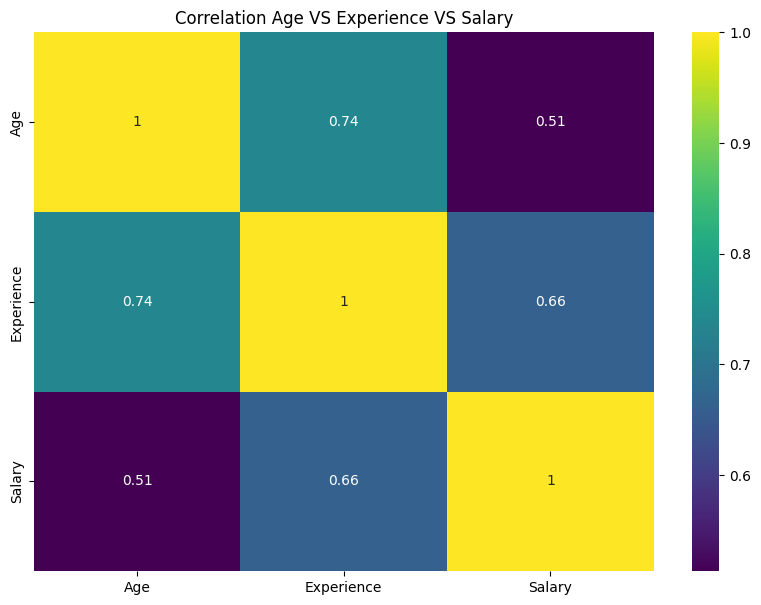

In [131]:
plt.figure(figsize=[10,7])
sns.heatmap(correlation_matrix,annot=True, cmap='viridis')
plt.title('Correlation Age VS Experience VS Salary',fontdict={'family': 'sans-serif'})
plt.show()

Show Barplot Count Education Level

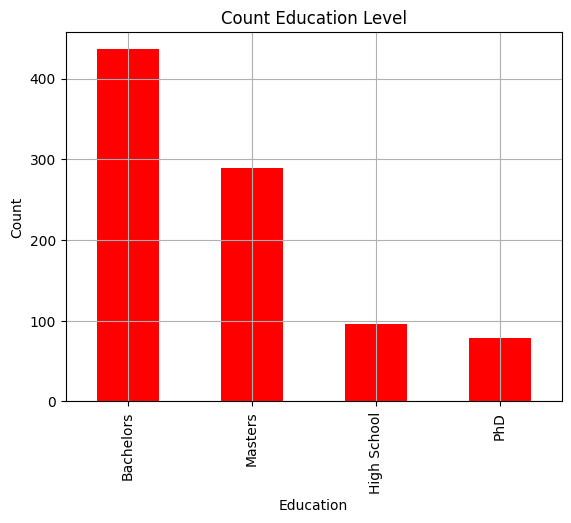

In [132]:
df['Education_Level'].value_counts().plot(kind='bar',color='red')
plt.title('Count Education Level')
plt.xlabel('Education')
plt.ylabel('Count')
plt.grid(True)
plt.show()

Check Outliers of Age columns in Boxplot

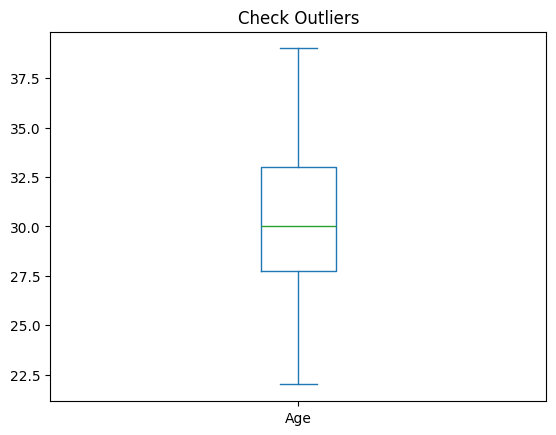

In [133]:
df['Age'].plot(kind='box')
plt.title('Check Outliers')
plt.show()

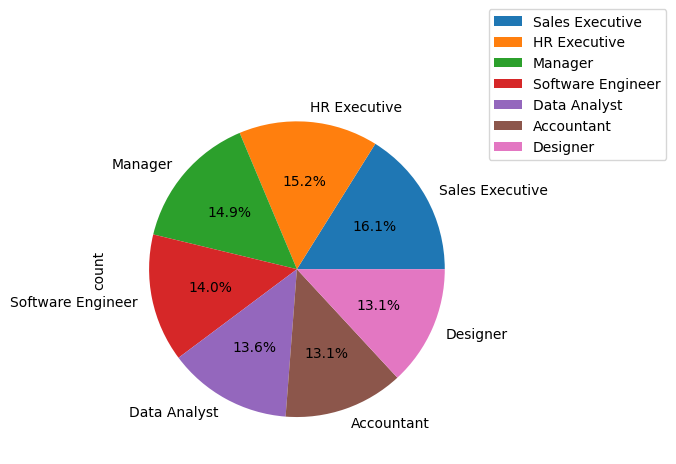

In [134]:
job_role_counts = df['Job_Role'].value_counts()
job_role_counts.plot(kind='pie', autopct='%1.1f%%')
plt.legend(job_role_counts.index, loc='center left', bbox_to_anchor=(1, 0, 0.5, 2))
plt.show()

## Encoding Categorical Variables

I will encode the categorical columns into numerical representations for further analysis.
*   `Education_Level` will be ordinal encoded as there's a clear hierarchy.
*   `Job_Role` and `Location` will be one-hot encoded as they are nominal categories.

In [138]:
# Ordinal encode 'Education_Level' using the predefined order
edu_order = {'High School': 0, 'Bachelors': 1, 'Masters': 2, 'PhD': 3}
if 'Education_Level' in df.columns:
    df['Education_Level_Encoded'] = df['Education_Level'].map(edu_order)

# One-hot encode 'Job_Role' and 'Location'
columns_to_onehot = [col for col in ['Job_Role', 'Location'] if col in df.columns]
if columns_to_onehot:
    df = pd.get_dummies(df, columns=columns_to_onehot, drop_first=True)

# Drop the original 'Education_Level' column as it's now encoded
if 'Education_Level' in df.columns:
    df = df.drop(columns=['Education_Level'])

## Feature and Target Separation, Scaling, and Train-Test Split

I will now separate the features (`X`) from the target variable (`y`, which is 'Salary'). After that, I will apply `StandardScaler` to the numerical features in `X` to standardize their range. Finally, the data will be split into training and testing sets to prepare for model training and evaluation.

In [141]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df.drop('Salary', axis=1)
y = df['Salary']

# Identify numerical columns in X that need scaling
# These are 'Age', 'Experience', and 'Education_Level_Encoded'
numerical_cols_to_scale = ['Age', 'Experience']
if 'Education_Level_Encoded' in X.columns:
    numerical_cols_to_scale.append('Education_Level_Encoded')

# Initialize and apply StandardScaler to the selected numerical columns in X
scaler = StandardScaler()
X[numerical_cols_to_scale] = scaler.fit_transform(X[numerical_cols_to_scale])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (720, 15)
Shape of X_test: (180, 15)
Shape of y_train: (720,)
Shape of y_test: (180,)


Import Linear Regression

In [143]:
from sklearn.linear_model import LinearRegression

set model in variable name

In [144]:
lr = LinearRegression()

fit data into model

In [145]:
lr.fit(X_train,y_train)

LinearRegression()

In [148]:
y_pred = lr.predict(X_test)

Model Evaluation

In [149]:
from sklearn.metrics import r2_score, mean_squared_error

In [152]:
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)

Check r2_score and mean_squared_error

In [160]:
print(f'r2_score = {r2 * 100:.2f}%')
print(f'the Mean Squared Error = {mse:.2f}')

r2_score = 78.60%
the Mean Squared Error = 31839646.66


Check Cross_Validation

In [161]:
from sklearn.model_selection import cross_val_score

In [181]:
validation = cross_val_score(lr, X, y, cv=15, n_jobs=-1)

In [182]:
print(validation)

[0.75584151 0.81090675 0.81335387 0.75591318 0.82821576 0.82379814
 0.76964846 0.78772652 0.7619481  0.77127229 0.77300111 0.82081535
 0.7949943  0.82207566 0.80304532]
